# Clinical NLP & RAG Assistant
### A medical text classification and retrieval-augmented generation pipeline

**Author:** SAAL Nour Amani — [github.com/AmaniS1436](https://github.com/AmaniS1436)

**Environment:** Google Colab, single NVIDIA T4 GPU (free tier)

---

## What this notebook demonstrates

This project is an AI-engineering portfolio piece, not a clinical or diagnostic tool. It walks through a complete pipeline applied to the medical text domain:

1. **Medical text classification** — a classical TF-IDF + Logistic Regression baseline compared against a fine-tuned domain-specific Transformer (BioBERT).
2. **Retrieval-Augmented Generation (RAG)** — a small medical knowledge base built from a public WHO fact sheet, indexed with sentence embeddings and ChromaDB, queried by a lightweight instruction-following LLM (FLAN-T5-base), with an explicit **abstention mechanism** for out-of-domain questions.

> **Scope disclaimer.** This system is an engineering prototype for learning and portfolio purposes. It has **not** been clinically validated, is **not** intended for diagnosis or treatment decisions, and should never be used as a source of medical advice. Every result below is exactly what was measured in this notebook — nothing has been extrapolated or embellished, and the limitations found during testing are documented rather than hidden.

---
## 0. Project Setup

**Stack:** Python, Pandas, NumPy, scikit-learn, Matplotlib, Hugging Face `transformers` / `datasets`, PyTorch, Sentence-Transformers, ChromaDB, `pypdf`, `requests`, BeautifulSoup.

**Why Google Colab + a single T4 GPU?** The goal was a pipeline that is fast to iterate on, fully reproducible, runs on a free-tier environment, and is still realistic enough to demonstrate the core skills of an AI engineer (fine-tuning a Transformer, building a vector store, wiring up a RAG loop) without needing paid infrastructure.

In [1]:
!pip -q install \
    datasets \
    transformers \
    accelerate \
    evaluate \
    sentence-transformers \
    chromadb \
    pypdf


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Environment ready.")

Environment ready.


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [4]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


---
# Part 1 — Clinical Text Classification

## 1. Dataset & Exploratory Data Analysis

**Dataset:** [`TimSchopf/medical_abstracts`](https://huggingface.co/datasets/TimSchopf/medical_abstracts) — 14,438 medical abstracts labeled into 5 condition categories: neoplasms, digestive system diseases, nervous system diseases, cardiovascular diseases, and general pathological conditions.

In [5]:
from datasets import load_dataset

dataset = load_dataset("TimSchopf/medical_abstracts")

dataset

DatasetDict({
    train: Dataset({
        features: ['condition_label', 'medical_abstract'],
        num_rows: 11550
    })
    test: Dataset({
        features: ['condition_label', 'medical_abstract'],
        num_rows: 2888
    })
})

In [6]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (11550, 2)
Test shape: (2888, 2)


,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."
3,1,Lipolytic factors associated with murine and h...
4,3,Does carotid restenosis predict an increased r...


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11550 entries, 0 to 11549
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   condition_label   11550 non-null  int64 
 1   medical_abstract  11550 non-null  object
dtypes: int64(1), object(1)
memory usage: 180.6+ KB


**Missing values** — none in either split.

In [8]:
train_df.isna().sum()

,0
condition_label,0
medical_abstract,0


In [9]:
test_df.isna().sum()

,0
condition_label,0
medical_abstract,0


**Duplicates within each split individually** — none, but this check alone is not enough (see the leakage check below).

In [10]:
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


**Label distribution** (raw, before cleaning) and the human-readable category names:

In [11]:
label_counts = train_df["condition_label"].value_counts().sort_index()

label_counts

,count
condition_label,
1,2530
2,1195
3,1540
4,2441
5,3844


In [12]:
label_dataset = load_dataset(
    "TimSchopf/medical_abstracts",
    name="labels"
)

label_df = label_dataset["train"].to_pandas()

label_df

,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


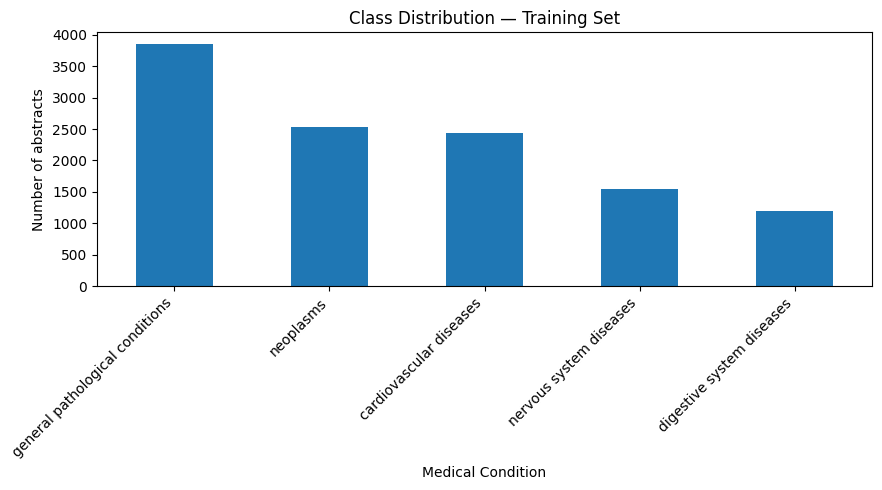

In [13]:
plt.figure(figsize=(9, 5))

train_df["condition_name"].value_counts().plot(kind="bar")

plt.title("Class Distribution — Training Set")
plt.xlabel("Medical Condition")
plt.ylabel("Number of abstracts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Text length distribution** — abstracts are, on average, ~1,230 characters (~180 words) long.

In [14]:
train_df["text_length_chars"] = (
    train_df["medical_abstract"]
    .astype(str)
    .str.len()
)

train_df["text_length_words"] = (
    train_df["medical_abstract"]
    .astype(str)
    .str.split()
    .str.len()
)

train_df[
    ["text_length_chars", "text_length_words"]
].describe()

,text_length_chars,text_length_words
count,11550.000000,11550.000000
mean,1229.104156,179.640606
std,505.960982,76.369776
min,170.000000,24.000000
25%,847.000000,122.000000
50%,1208.000000,175.000000
75%,1587.000000,234.000000
max,3999.000000,596.000000


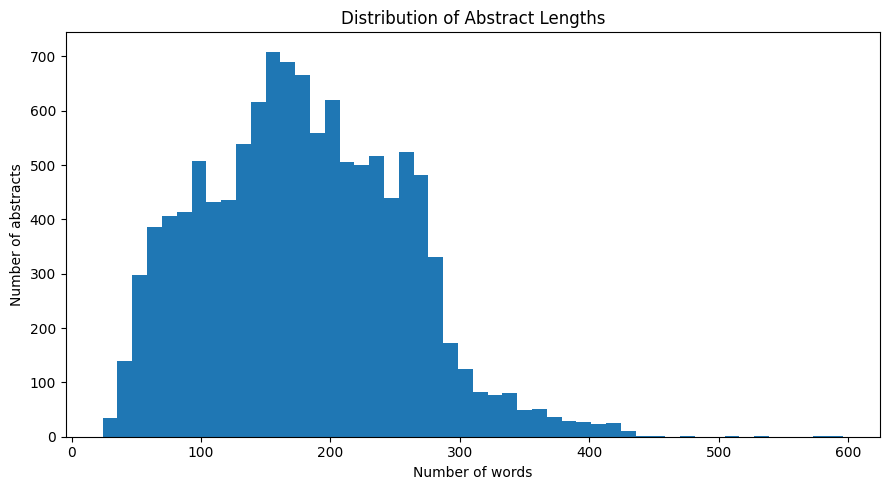

In [15]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_df["text_length_words"],
    bins=50
)

plt.title("Distribution of Abstract Lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of abstracts")

plt.tight_layout()
plt.show()

In [16]:
train_df.groupby("condition_name")[
    "text_length_words"
].describe()

,count,mean,std,min,25%,50%,75%,max
condition_name,,,,,,,,
cardiovascular diseases,2441.0,200.134781,80.256941,28.0,142.0,205.0,260.0,578.0
digestive system diseases,1195.0,178.662762,71.528368,30.0,124.0,179.0,227.0,417.0
general pathological conditions,3844.0,177.059573,75.754990,24.0,120.0,171.0,231.0,528.0
neoplasms,2530.0,174.173913,75.104144,24.0,119.0,171.0,222.0,422.0
nervous system diseases,1540.0,163.338312,70.623606,31.0,109.0,158.0,212.0,596.0


### 1.1 Data quality check — duplicate and label-conflict analysis

Before training anything, the train and test splits were concatenated and checked for **exact text duplicates** and **texts that appear with conflicting labels**. This step matters because unnoticed train/test overlap silently inflates evaluation metrics.

In [17]:
train_texts = set(train_df["medical_abstract"].astype(str))
test_texts = set(test_df["medical_abstract"].astype(str))

overlap = train_texts.intersection(test_texts)

print("Exact text overlap:", len(overlap))

Exact text overlap: 988


In [18]:
overlap_examples = list(overlap)[:5]

for i, text in enumerate(overlap_examples, 1):
    print(f"\n--- Example {i} ---")
    print(text[:1000])


--- Example 1 ---
T cell subsets (Tc, Th, Ts, Tsi) and IL2 receptor-bearing cells in peripheral blood of patients in the acute phase of alcoholic hepatitis. The present study was designed to evaluate the proportion of T cell subsets and IL2 receptor positive cells in the peripheral blood of patients with acute alcoholic hepatitis (AAH) using monoclonal antibodies to T cell antigens and Tac in a double immunofluorescent technique. The results indicate that the percentage of the total T cells and the intensity of all the T cell antigens are significantly reduced and the percentage of T helper cells and the ratio between Th/Ts cells are significantly increased in AAH when compared to healthy controls. But, significant differences in values observed in this study were not found for the absolute number of these cells. These altered values returned to normal levels during convalescence. 

--- Example 2 ---
Laparoscopic cholecystectomy: an initial report. Sixty consecutive patients underwent

**Result:** 988 texts were found identically in both the original train and test splits — a real risk of data leakage if left unaddressed.

In [19]:
# Combine the original train and test sets
all_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

# Keep only texts that appear more than once
duplicate_texts = (
    all_df[
        all_df["medical_abstract"].duplicated(keep=False)
    ]
    .sort_values("medical_abstract")
)

print("Number of rows involved in duplicated texts:",
      len(duplicate_texts))

print("Number of unique duplicated texts:",
      duplicate_texts["medical_abstract"].nunique())

Number of rows involved in duplicated texts: 6140
Number of unique duplicated texts: 2929


In [20]:
# Show a few duplicated texts with conflicting labels

conflicting_texts = (
    duplicate_texts[
        duplicate_texts["medical_abstract"].isin(
            conflicting_duplicates.index
        )
    ]
    .groupby("medical_abstract")
    .agg(
        labels=("condition_label", lambda x: sorted(set(x))),
        n_occurrences=("condition_label", "size")
    )
    .reset_index()
)

conflicting_texts.head(5)

,medical_abstract,labels,n_occurrences
0,'Locked-in syndrome' for 27 years following a ...,"[1, 3, 5]",3
1,(A)typical symptoms during single needle dialy...,"[2, 4, 5]",3
2,7th nerve palsy after extradural blood patch. ...,"[3, 5]",2
3,99TCm-HMPAO SPECT studies in traumatic intrace...,"[3, 5]",2
4,A 5.3-kb deletion including exon XIII of the p...,"[4, 5]",2


2,929 unique texts were associated with more than one label across the dataset (the same abstract tagged with different condition labels in different rows) — these are inherently ambiguous for a single-label classifier and were excluded rather than arbitrarily resolved.

In [21]:
# Number of unique texts
unique_texts = all_df["medical_abstract"].nunique()

# Texts appearing more than once
text_label_counts = (
    all_df
    .groupby("medical_abstract")["condition_label"]
    .nunique()
)

# Unambiguous texts = exactly one label
unambiguous_texts = text_label_counts[
    text_label_counts == 1
].index

# Ambiguous texts = multiple labels
ambiguous_texts = text_label_counts[
    text_label_counts > 1
].index

print("Total rows:", len(all_df))
print("Unique texts:", unique_texts)
print("Unambiguous unique texts:", len(unambiguous_texts))
print("Ambiguous unique texts:", len(ambiguous_texts))
print("Rows to potentially keep:", all_df["medical_abstract"].isin(unambiguous_texts).sum())

Total rows: 14438
Unique texts: 11227
Unambiguous unique texts: 8298
Ambiguous unique texts: 2929
Rows to potentially keep: 8298


### 1.2 Cleaning decision

**Kept:** only unique, unambiguous texts (a single label per text, no duplicates). **Dropped:** the 988 exact-duplicate rows and the 2,929 texts with conflicting labels.

This reduces the dataset from 14,438 rows to a clean **8,298 documents**, but the resulting metrics are trustworthy — the alternative (training on leaked/ambiguous data) would look better on paper while being methodologically unsound.

In [22]:
clean_df = all_df[
    all_df["medical_abstract"].isin(unambiguous_texts)
].copy()

# Keep one row per unique text
clean_df = clean_df.drop_duplicates(
    subset="medical_abstract"
).reset_index(drop=True)

print("Clean dataset shape:", clean_df.shape)
print(
    "Unique texts:",
    clean_df["medical_abstract"].nunique()
)

Clean dataset shape: (8298, 5)
Unique texts: 8298


In [23]:
print(
    clean_df["condition_label"]
    .value_counts()
    .sort_index()
)

condition_label
1    2195
2     699
3    1049
4    1961
5    2394
Name: count, dtype: int64


In [24]:
print(
    "Duplicated texts:",
    clean_df["medical_abstract"].duplicated().sum()
)

Duplicated texts: 0


In [25]:
label_check = (
    clean_df
    .groupby("medical_abstract")["condition_label"]
    .nunique()
)

print(
    "Texts with multiple labels:",
    (label_check > 1).sum()
)

Texts with multiple labels: 0


### 1.3 Stratified train / validation / test split

A stratified split preserves the class proportions across all three sets, and an explicit overlap check confirms there is no leakage between them.

In [26]:
from sklearn.model_selection import train_test_split

X = clean_df["medical_abstract"]
y = clean_df["condition_label"]

# 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

# 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 6638
Validation: 830
Test: 830


In [27]:
split_distribution = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).sort_index()

split_distribution

,Train,Validation,Test
condition_label,,,
1,0.264538,0.263855,0.265060
2,0.084212,0.084337,0.084337
3,0.126393,0.126506,0.126506
4,0.236366,0.236145,0.236145
5,0.288491,0.289157,0.287952


In [28]:
print("Train ∩ Validation:",
      len(set(X_train) & set(X_val)))

print("Train ∩ Test:",
      len(set(X_train) & set(X_test)))

print("Validation ∩ Test:",
      len(set(X_val) & set(X_test)))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## 2. Text Preprocessing

Preprocessing was kept deliberately light: Transformer models rely on the linguistic structure of the text (word order, punctuation, casing), so aggressive cleaning would throw away useful signal. Labels were re-mapped from the original 1–5 scheme to 0–4 for the Transformer. For the TF-IDF baseline specifically: lowercasing, English stop-word removal, unigrams + bigrams, `max_features=30000`, `min_df=2`.

## 3. Baseline Model — TF-IDF + Logistic Regression

A classical, fully interpretable baseline before reaching for a Transformer — this is the model any improvement has to beat, and it also gives a fast sanity check on the whole pipeline.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Train matrix:", X_train_tfidf.shape)
print("Validation matrix:", X_val_tfidf.shape)
print("Test matrix:", X_test_tfidf.shape)

Train matrix: (6638, 30000)
Validation matrix: (830, 30000)
Test matrix: (830, 30000)


In [30]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

baseline_model.fit(X_train_tfidf, y_train)

print("Baseline model trained.")

Baseline model trained.


In [31]:
from sklearn.metrics import accuracy_score, f1_score

y_val_pred = baseline_model.predict(X_val_tfidf)

accuracy = accuracy_score(y_val, y_val_pred)
macro_f1 = f1_score(y_val, y_val_pred, average="macro")

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro-F1: {macro_f1:.4f}")

Validation Accuracy: 0.8181
Validation Macro-F1: 0.8205


In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           1     0.9034    0.8539    0.8779       219
           2     0.7975    0.9000    0.8456        70
           3     0.7350    0.8190    0.7748       105
           4     0.8842    0.8571    0.8705       196
           5     0.7384    0.7292    0.7338       240

    accuracy                         0.8181       830
   macro avg     0.8117    0.8318    0.8205       830
weighted avg     0.8209    0.8181    0.8187       830



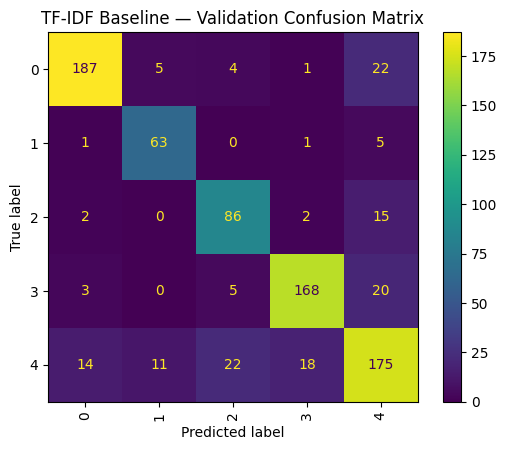

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    xticks_rotation="vertical"
)

plt.title("TF-IDF Baseline — Validation Confusion Matrix")
plt.show()

**Validation:** Accuracy 0.8181, Macro-F1 0.8205. Inspecting a sample of the errors:

In [34]:
val_results = pd.DataFrame({
    "text": X_val.values,
    "true_label": y_val.values,
    "predicted_label": y_val_pred
})

errors = val_results[
    val_results["true_label"] != val_results["predicted_label"]
].copy()

print("Number of errors:", len(errors))
errors.head(10)

Number of errors: 151


,text,true_label,predicted_label
0,Hepatic injury induced by bile salts: correlat...,5,2
23,1990 Volvo Award in clinical sciences. Lumbar ...,5,3
26,Diagnostic modalities in abdominal trauma. Per...,5,2
32,US-assisted aspiration thrombectomy: in vitro ...,4,5
33,Expressional potency of mRNAs encoding recepto...,5,3
40,Characterization in vitro of a human tumor nec...,1,5
45,Centrifugal intensity and duration as counterm...,3,5
49,Neuropsychological outcome of survivors of out...,4,3
54,Decrease in mean platelet survival time in acu...,5,4
61,Diagnostic utility of lower extremity radiogra...,3,5


**Which classes get confused with which?**

In [35]:
label_mapping

{1: 'neoplasms',
 2: 'digestive system diseases',
 3: 'nervous system diseases',
 4: 'cardiovascular diseases',
 5: 'general pathological conditions'}

In [36]:
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{label_mapping[i]}" for i in sorted(label_mapping)],
    columns=[f"Pred_{label_mapping[i]}" for i in sorted(label_mapping)]
)

cm_df

,Pred_neoplasms,Pred_digestive system diseases,Pred_nervous system diseases,Pred_cardiovascular diseases,Pred_general pathological conditions
True_neoplasms,187,5,4,1,22
True_digestive system diseases,1,63,0,1,5
True_nervous system diseases,2,0,86,2,15
True_cardiovascular diseases,3,0,5,168,20
True_general pathological conditions,14,11,22,18,175


In [37]:
confusions = []

labels = sorted(label_mapping)

for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j:
            confusions.append({
                "true_label": label_mapping[true_label],
                "predicted_label": label_mapping[pred_label],
                "count": cm[i, j]
            })

confusions_df = (
    pd.DataFrame(confusions)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

confusions_df.head(10)

,true_label,predicted_label,count
0,neoplasms,general pathological conditions,22
1,general pathological conditions,nervous system diseases,22
2,cardiovascular diseases,general pathological conditions,20
3,general pathological conditions,cardiovascular diseases,18
4,nervous system diseases,general pathological conditions,15
5,general pathological conditions,neoplasms,14
6,general pathological conditions,digestive system diseases,11
7,neoplasms,digestive system diseases,5
8,cardiovascular diseases,nervous system diseases,5
9,digestive system diseases,general pathological conditions,5


The confusions concentrate around **general pathological conditions**, which is unsurprising: it is the broadest, most heterogeneous category and shares vocabulary with several of the other, more specific classes (neoplasms, cardiovascular, nervous system). TF-IDF gives a solid, interpretable baseline, but it captures surface-level word overlap rather than deeper semantic context — which is exactly the gap a domain-specific Transformer is expected to close.

## 4. Transformer Model — BioBERT

**Model:** [`dmis-lab/biobert-v1.1`](https://huggingface.co/dmis-lab/biobert-v1.1), chosen because it is pre-trained on biomedical text, making it a natural fit for classifying medical abstracts (compared to a general-purpose BERT).

**Training configuration:** max sequence length 512, learning rate 2e-5, batch size 8 (train) / 16 (eval), 3 epochs, weight decay 0.01, mixed precision (fp16), best checkpoint selected on validation Macro-F1.

In [38]:
from datasets import Dataset

label_ids = sorted(clean_df["condition_label"].unique())

label2id = {
    label: idx
    for idx, label in enumerate(label_ids)
}

id2label = {
    idx: label_mapping[label]
    for label, idx in label2id.items()
}

print("label2id:", label2id)
print("id2label:", id2label)

label2id: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4}
id2label: {0: 'neoplasms', 1: 'digestive system diseases', 2: 'nervous system diseases', 3: 'cardiovascular diseases', 4: 'general pathological conditions'}


In [39]:
train_transformer_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.map(label2id).values
})

val_transformer_df = pd.DataFrame({
    "text": X_val.values,
    "label": y_val.map(label2id).values
})

test_transformer_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.map(label2id).values
})

print(train_transformer_df.shape)
print(val_transformer_df.shape)
print(test_transformer_df.shape)

(6638, 2)
(830, 2)
(830, 2)


In [40]:
train_dataset = Dataset.from_pandas(
    train_transformer_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_transformer_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_transformer_df,
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 6638
})
Dataset({
    features: ['text', 'label'],
    num_rows: 830
})
Dataset({
    features: ['text', 'label'],
    num_rows: 830
})


In [41]:
from transformers import AutoTokenizer

MODEL_NAME = "dmis-lab/biobert-v1.1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)

Tokenizer loaded: dmis-lab/biobert-v1.1


In [42]:
sample_text = train_dataset[0]["text"]

tokens = tokenizer(
    sample_text,
    truncation=True,
    max_length=512
)

print("Original text length:", len(sample_text))
print("Number of tokens:", len(tokens["input_ids"]))
print("First token IDs:", tokens["input_ids"][:20])

Original text length: 1377
Number of tokens: 355
First token IDs: [101, 1302, 4006, 1104, 2569, 1139, 13335, 2881, 2916, 1110, 4386, 8191, 1219, 1137, 1170, 1610, 3329, 2386, 1322, 26579]


In [43]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print(tokenized_train)

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6638
})


In [44]:
print(tokenized_train[0].keys())
print("Number of tokens:", len(tokenized_train[0]["input_ids"]))

dict_keys(['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])
Number of tokens: 355


In [45]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label2id)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id={
        str(k): v for k, v in label2id.items()
    }
)

print("Model loaded.")
print("Number of labels:", model.config.num_labels)

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
Number of labels: 5


In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print("Device:", device)

Device: cuda


Metrics function, training arguments and `Trainer` setup:

In [47]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [48]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./biobert_medical_classifier",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=True,

    logging_steps=50,

    report_to="none"
)

In [49]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


Training ran for 3 epochs; validation Macro-F1 improved from 0.868 (epoch 1) to 0.894 (epoch 2), then plateaued at 0.894 (epoch 3) — **epoch 2** was selected as the best checkpoint.

In [50]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.565353,0.377143,0.873494,0.867966
2,0.315787,0.381703,0.897590,0.894282
3,0.261840,0.401102,0.897590,0.894029


**Held-out test set evaluation:**

In [51]:
test_results = trainer.evaluate(
    tokenized_test
)

test_results

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.261840,0.442748,3,0.868675,0.858329


{'eval_loss': 0.44274792075157166,
 'eval_accuracy': 0.8686746987951808,
 'eval_macro_f1': 0.8583291868325654}

In [52]:
test_predictions = trainer.predict(tokenized_test)

test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids

test_pred_labels = np.argmax(
    test_logits,
    axis=-1
)

print("Predictions:", len(test_pred_labels))
print("True labels:", len(test_labels))

Predictions: 830
True labels: 830


In [53]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        test_pred_labels,
        target_names=[
            id2label[i]
            for i in range(len(id2label))
        ],
        digits=4
    )
)

                                 precision    recall  f1-score   support

                      neoplasms     0.9095    0.9591    0.9336       220
      digestive system diseases     0.8871    0.7857    0.8333        70
        nervous system diseases     0.8077    0.8000    0.8038       105
        cardiovascular diseases     0.9020    0.9388    0.9200       196
general pathological conditions     0.8202    0.7824    0.8009       239

                       accuracy                         0.8687       830
                      macro avg     0.8653    0.8532    0.8583       830
                   weighted avg     0.8672    0.8687    0.8673       830



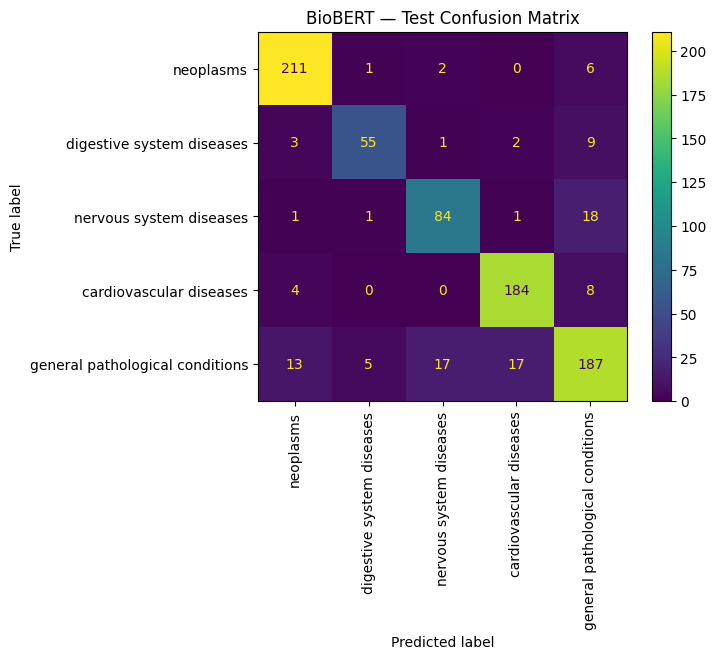

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_biobert = confusion_matrix(
    test_labels,
    test_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_biobert,
    display_labels=[
        id2label[i]
        for i in range(len(id2label))
    ]
)

disp.plot(
    xticks_rotation="vertical"
)

plt.title("BioBERT — Test Confusion Matrix")
plt.show()

## 5. Model Comparison & Error Analysis

Re-evaluating the TF-IDF baseline on the exact same test set as BioBERT, for a fair comparison:

In [55]:
y_test_pred_tfidf = baseline_model.predict(X_test_tfidf)

tfidf_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_tfidf
)

tfidf_test_macro_f1 = f1_score(
    y_test,
    y_test_pred_tfidf,
    average="macro"
)

print(f"TF-IDF Test Accuracy: {tfidf_test_accuracy:.4f}")
print(f"TF-IDF Test Macro-F1: {tfidf_test_macro_f1:.4f}")

TF-IDF Test Accuracy: 0.8181
TF-IDF Test Macro-F1: 0.8085


In [56]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "BioBERT"
    ],
    "Test Accuracy": [
        tfidf_test_accuracy,
        test_results["eval_accuracy"]
    ],
    "Test Macro-F1": [
        tfidf_test_macro_f1,
        test_results["eval_macro_f1"]
    ]
})

comparison

,Model,Test Accuracy,Test Macro-F1
0,TF-IDF + Logistic Regression,0.818072,0.808509
1,BioBERT,0.868675,0.858329


In [57]:
print(
    classification_report(
        y_test,
        y_test_pred_tfidf,
        target_names=[
            label_mapping[i]
            for i in sorted(label_mapping)
        ],
        digits=4
    )
)

                                 precision    recall  f1-score   support

                      neoplasms     0.9187    0.8727    0.8951       220
      digestive system diseases     0.7778    0.8000    0.7887        70
        nervous system diseases     0.7143    0.7619    0.7373       105
        cardiovascular diseases     0.8621    0.8929    0.8772       196
general pathological conditions     0.7521    0.7364    0.7442       239

                       accuracy                         0.8181       830
                      macro avg     0.8050    0.8128    0.8085       830
                   weighted avg     0.8196    0.8181    0.8185       830



In [58]:
confusions_biobert = []

labels = list(range(len(id2label)))

for i in labels:
    for j in labels:
        if i != j and cm_biobert[i, j] > 0:
            confusions_biobert.append({
                "true_label": id2label[i],
                "predicted_label": id2label[j],
                "count": cm_biobert[i, j]
            })

confusions_biobert_df = (
    pd.DataFrame(confusions_biobert)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

confusions_biobert_df.head(10)

,true_label,predicted_label,count
0,nervous system diseases,general pathological conditions,18
1,general pathological conditions,nervous system diseases,17
2,general pathological conditions,cardiovascular diseases,17
3,general pathological conditions,neoplasms,13
4,digestive system diseases,general pathological conditions,9
5,cardiovascular diseases,general pathological conditions,8
6,neoplasms,general pathological conditions,6
7,general pathological conditions,digestive system diseases,5
8,cardiovascular diseases,neoplasms,4
9,digestive system diseases,neoplasms,3


**BioBERT improves over the TF-IDF baseline by roughly +5.1 points of accuracy and +5.0 points of Macro-F1** (81.8% → 86.9% accuracy, 80.9% → 85.8% Macro-F1). Both models struggle with the same class for the same underlying reason: **general pathological conditions** is a broad, catch-all category whose vocabulary overlaps with the other four, more specific classes. BioBERT's biomedical pre-training clearly helps it capture more semantic nuance than surface-level n-grams, but it does not fully resolve this structural ambiguity in the dataset itself.

---
# Part 2 — Retrieval-Augmented Generation

## 6. Building the Knowledge Base

**Source:** the [WHO Cancer Fact Sheet](https://www.who.int/news-room/fact-sheets/detail/cancer), scraped and cleaned with `requests` + BeautifulSoup.

**Known limitation:** the extraction misses some content from nested HTML lists on the WHO page — a scraping limitation rather than a modeling one, documented here rather than hidden.

In [59]:
from pathlib import Path

DOCS_DIR = Path("medical_docs")
DOCS_DIR.mkdir(exist_ok=True)

print("Documents directory:", DOCS_DIR.resolve())

Documents directory: /content/medical_docs


In [60]:
import requests

print("requests:", requests.__version__)

requests: 2.32.4


In [61]:
import requests
from pathlib import Path

url = "https://www.who.int/news-room/fact-sheets/detail/cancer"

response = requests.get(url, timeout=30)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("content-type"))
print("Downloaded bytes:", len(response.content))

Status code: 200
Content type: text/html; charset=utf-8
Downloaded bytes: 124217


In [62]:
# Inspecter les balises HTML qui contiennent le contenu principal
main = soup.find("main")

print("Main section found:", main is not None)

if main:
    main_text = main.get_text(
        separator=" ",
        strip=True
    )

    print("Main text characters:", len(main_text))
    print("\nFirst 1500 characters:\n")
    print(main_text[:1500])

Main section found: False


In [63]:
# Afficher les balises contenant des paragraphes
paragraphs = soup.find_all("p")

print("Number of <p> elements:", len(paragraphs))

for i, p in enumerate(paragraphs[:10]):
    text_p = p.get_text(" ", strip=True)
    print(f"\n[{i}] {text_p[:300]}")

Number of <p> elements: 44

[0] Key facts

[1] Overview

[2] Cancer is a generic term for a large group of diseases that can affect any part of the body. Other terms used are malignant tumours and neoplasms. One defining
        feature of cancer is the rapid creation of abnormal cells that grow beyond their usual boundaries, and which can then invade adjoin

[3] Cancer is a leading cause of death worldwide, accounting for nearly 10 million deaths in 2024 (1) . The most common in 2024 (in terms of new cases of cancer) were:

[4] The most common causes of cancer death in 2024 were:

[5] The most common cancers vary between countries, and cervical cancer is the most common cancer among women in 26 countries, primarily in sub-Saharan Africa and parts of South and Central America, Melanesia and South‐East Asia.

[6] Cancer is a leading cause of death for children and adolescents. Each year, approximately 400 000 children and adolescents of 0–19 years old develop cancer (2) .

[7] Cancer ar

In [64]:
medical_paragraphs = []

for p in paragraphs:
    text_p = p.get_text(" ", strip=True)

    if len(text_p) >= 40:
        medical_paragraphs.append(text_p)

medical_text = "\n\n".join(medical_paragraphs)

print("Medical paragraphs:", len(medical_paragraphs))
print("Medical text characters:", len(medical_text))

print("\nFirst 2000 characters:\n")
print(medical_text[:2000])

Medical paragraphs: 34
Medical text characters: 8398

First 2000 characters:

Cancer is a generic term for a large group of diseases that can affect any part of the body. Other terms used are malignant tumours and neoplasms. One defining
        feature of cancer is the rapid creation of abnormal cells that grow beyond their usual boundaries, and which can then invade adjoining parts of the body and spread to other organs; the latter process is referred to as metastasis. Widespread metastases
        are the primary cause of death from cancer.

Cancer is a leading cause of death worldwide, accounting for nearly 10 million deaths in 2024 (1) . The most common in 2024 (in terms of new cases of cancer) were:

The most common causes of cancer death in 2024 were:

The most common cancers vary between countries, and cervical cancer is the most common cancer among women in 26 countries, primarily in sub-Saharan Africa and parts of South and Central America, Melanesia and South‐East Asia.

Can

In [65]:
doc_path = DOCS_DIR / "who_cancer.txt"

doc_path.write_text(
    medical_text,
    encoding="utf-8"
)

print("Saved:", doc_path)
print("File size:", doc_path.stat().st_size, "bytes")

Saved: medical_docs/who_cancer.txt
File size: 8412 bytes


In [66]:
import re

clean_medical_text = re.sub(r"\s+", " ", medical_text)
clean_medical_text = clean_medical_text.strip()

print("Caractères avant nettoyage :", len(medical_text))
print("Caractères après nettoyage :", len(clean_medical_text))

print("\nAperçu :\n")
print(clean_medical_text[:2000])

Caractères avant nettoyage : 8398
Caractères après nettoyage : 8230

Aperçu :

Cancer is a generic term for a large group of diseases that can affect any part of the body. Other terms used are malignant tumours and neoplasms. One defining feature of cancer is the rapid creation of abnormal cells that grow beyond their usual boundaries, and which can then invade adjoining parts of the body and spread to other organs; the latter process is referred to as metastasis. Widespread metastases are the primary cause of death from cancer. Cancer is a leading cause of death worldwide, accounting for nearly 10 million deaths in 2024 (1) . The most common in 2024 (in terms of new cases of cancer) were: The most common causes of cancer death in 2024 were: The most common cancers vary between countries, and cervical cancer is the most common cancer among women in 26 countries, primarily in sub-Saharan Africa and parts of South and Central America, Melanesia and South‐East Asia. Cancer is a leading ca

## 7. Document Chunking

### 7.1 First attempt — fixed-size character chunks (rejected)

The first chunker simply cut the text every *N* characters. This is fast, but it slices straight through words and sentences with no regard for meaning:

In [67]:
def create_chunks(text, chunk_size=500, overlap=100):
    chunks = []

    start = 0

    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end].strip()

        if chunk:
            chunks.append(chunk)

        start += chunk_size - overlap

    return chunks


chunks = create_chunks(
    clean_medical_text,
    chunk_size=500,
    overlap=100
)

print("Nombre de chunks :", len(chunks))

Nombre de chunks : 21


In [68]:
for i, chunk in enumerate(chunks[:5]):
    print(f"\n{'='*80}")
    print(f"CHUNK {i}")
    print(f"Longueur : {len(chunk)} caractères")
    print(f"{'='*80}")
    print(chunk)


CHUNK 0
Longueur : 500 caractères
Cancer is a generic term for a large group of diseases that can affect any part of the body. Other terms used are malignant tumours and neoplasms. One defining feature of cancer is the rapid creation of abnormal cells that grow beyond their usual boundaries, and which can then invade adjoining parts of the body and spread to other organs; the latter process is referred to as metastasis. Widespread metastases are the primary cause of death from cancer. Cancer is a leading cause of death worldwide

CHUNK 1
Longueur : 499 caractères
metastases are the primary cause of death from cancer. Cancer is a leading cause of death worldwide, accounting for nearly 10 million deaths in 2024 (1) . The most common in 2024 (in terms of new cases of cancer) were: The most common causes of cancer death in 2024 were: The most common cancers vary between countries, and cervical cancer is the most common cancer among women in 26 countries, primarily in sub-Saharan Africa an

### 7.2 Second attempt — sentence-aware chunking

Splitting on sentence boundaries fixes the mid-word cuts, but with a hard character budget it can still produce very short, fragment-like chunks:

In [69]:
import re

def create_sentence_chunks(text, chunk_size=500, overlap_sentences=1):
    sentences = re.split(r'(?<=[.!?])\s+', text)

    chunks = []
    current_sentences = []
    current_length = 0

    for sentence in sentences:
        sentence = sentence.strip()

        if not sentence:
            continue

        if current_sentences and current_length + len(sentence) + 1 > chunk_size:
            chunks.append(" ".join(current_sentences))

            # Garder la dernière phrase comme overlap
            current_sentences = current_sentences[-overlap_sentences:]
            current_length = sum(len(s) for s in current_sentences)

        current_sentences.append(sentence)
        current_length += len(sentence) + 1

    if current_sentences:
        chunks.append(" ".join(current_sentences))

    return chunks


chunks = create_sentence_chunks(
    clean_medical_text,
    chunk_size=500,
    overlap_sentences=1
)

print("Nombre de chunks :", len(chunks))

Nombre de chunks : 31


In [70]:
for i, chunk in enumerate(chunks[:5]):
    print(f"\n{'='*80}")
    print(f"CHUNK {i}")
    print(f"Longueur : {len(chunk)} caractères")
    print(f"{'='*80}")
    print(chunk)


CHUNK 0
Longueur : 455 caractères
Cancer is a generic term for a large group of diseases that can affect any part of the body. Other terms used are malignant tumours and neoplasms. One defining feature of cancer is the rapid creation of abnormal cells that grow beyond their usual boundaries, and which can then invade adjoining parts of the body and spread to other organs; the latter process is referred to as metastasis. Widespread metastases are the primary cause of death from cancer.

CHUNK 1
Longueur : 165 caractères
Widespread metastases are the primary cause of death from cancer. Cancer is a leading cause of death worldwide, accounting for nearly 10 million deaths in 2024 (1) .

CHUNK 2
Longueur : 442 caractères
Cancer is a leading cause of death worldwide, accounting for nearly 10 million deaths in 2024 (1) . The most common in 2024 (in terms of new cases of cancer) were: The most common causes of cancer death in 2024 were: The most common cancers vary between countries, and cerv

### 7.3 Final version — semantic (sentence-aware) chunking

The final chunker groups whole sentences up to a target size (~600 characters) and only carries a sentence over to the next chunk when it is short enough to be worth it as overlap. This keeps chunks coherent, avoids mid-sentence cuts, and improves retrieval quality by preserving local context.

In [71]:
def create_semantic_chunks(text, chunk_size=600):
    sentences = re.split(r'(?<=[.!?])\s+', text)

    chunks = []
    current_sentences = []
    current_length = 0

    for sentence in sentences:
        sentence = sentence.strip()

        if not sentence:
            continue

        sentence_length = len(sentence) + 1

        # Ajouter la phrase au chunk courant si elle tient
        if current_sentences and current_length + sentence_length > chunk_size:
            chunks.append(" ".join(current_sentences))

            # Commencer le nouveau chunk avec la dernière phrase
            # seulement si elle est suffisamment courte
            last_sentence = current_sentences[-1]

            if len(last_sentence) < chunk_size * 0.5:
                current_sentences = [last_sentence]
                current_length = len(last_sentence) + 1
            else:
                current_sentences = []
                current_length = 0

        current_sentences.append(sentence)
        current_length += sentence_length

    if current_sentences:
        chunks.append(" ".join(current_sentences))

    return chunks


chunks = create_semantic_chunks(
    clean_medical_text,
    chunk_size=600
)

print("Nombre de chunks :", len(chunks))

Nombre de chunks : 22


In [72]:
chunk_lengths = [len(chunk) for chunk in chunks]

print("Nombre de chunks :", len(chunks))
print("Taille minimale :", min(chunk_lengths))
print("Taille maximale :", max(chunk_lengths))
print("Taille moyenne :", round(sum(chunk_lengths) / len(chunk_lengths), 1))

print("\nPremiers chunks :")

for i, chunk in enumerate(chunks[:5]):
    print(f"\n{'='*80}")
    print(f"CHUNK {i} — {len(chunk)} caractères")
    print(f"{'='*80}")
    print(chunk)

Nombre de chunks : 22
Taille minimale : 325
Taille maximale : 623
Taille moyenne : 495.0

Premiers chunks :

CHUNK 0 — 555 caractères
Cancer is a generic term for a large group of diseases that can affect any part of the body. Other terms used are malignant tumours and neoplasms. One defining feature of cancer is the rapid creation of abnormal cells that grow beyond their usual boundaries, and which can then invade adjoining parts of the body and spread to other organs; the latter process is referred to as metastasis. Widespread metastases are the primary cause of death from cancer. Cancer is a leading cause of death worldwide, accounting for nearly 10 million deaths in 2024 (1) .

CHUNK 1 — 507 caractères
Cancer is a leading cause of death worldwide, accounting for nearly 10 million deaths in 2024 (1) . The most common in 2024 (in terms of new cases of cancer) were: The most common causes of cancer death in 2024 were: The most common cancers vary between countries, and cervical cancer

**Result:** 22 chunks, 325–623 characters each, ~495 characters on average.

## 8. Embeddings

**Model:** [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) — small, fast, and sufficient for a 22-chunk knowledge base. Each chunk is mapped to a 384-dimensional vector for semantic comparison against user questions.

In [73]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL)

print("Embedding model chargé :", EMBEDDING_MODEL)

Embedding model chargé : sentence-transformers/all-MiniLM-L6-v2


In [74]:
test_embedding = embedding_model.encode(
    chunks[0],
    convert_to_numpy=True
)

print("Type :", type(test_embedding))
print("Dimension :", test_embedding.shape)
print("Premiers éléments :", test_embedding[:10])

Type : <class 'numpy.ndarray'>
Dimension : (384,)
Premiers éléments : [ 0.0625376   0.02960846 -0.00289529 -0.04152936  0.00600794 -0.01868456
  0.04127647  0.06337307  0.01893483  0.01925447]


In [75]:
embeddings = embedding_model.encode(
    chunks,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Shape des embeddings :", embeddings.shape)

Shape des embeddings : (22, 384)


## 9. Vector Database — ChromaDB

`Question → embedding → nearest chunks`. ChromaDB stores each chunk's embedding alongside its text and metadata (source name, chunk id) for later source attribution.

In [76]:
import chromadb

chroma_client = chromadb.Client()

collection = chroma_client.get_or_create_collection(
    name="medical_knowledge"
)

print("Collection créée :", collection.name)

Collection créée : medical_knowledge


In [77]:
documents = chunks

ids = [f"chunk_{i}" for i in range(len(chunks))]

metadatas = [
    {
        "source": "WHO Cancer Fact Sheet",
        "chunk_id": i
    }
    for i in range(len(chunks))
]

print("Documents :", len(documents))
print("IDs :", len(ids))
print("Métadonnées :", len(metadatas))

Documents : 22
IDs : 22
Métadonnées : 22


In [78]:
collection.add(
    ids=ids,
    documents=documents,
    embeddings=embeddings.tolist(),
    metadatas=metadatas
)

print("Nombre de documents dans ChromaDB :", collection.count())

Nombre de documents dans ChromaDB : 22


## 10. Retrieval

Example query: *"What are the main risk factors for cancer?"* — top-3 nearest chunks by vector distance:

In [79]:
query = "What are the main risk factors for cancer?"

query_embedding = embedding_model.encode(
    query,
    convert_to_numpy=True
)

results = collection.query(
    query_embeddings=[query_embedding.tolist()],
    n_results=3
)

print("Question :", query)

for i, document in enumerate(results["documents"][0]):
    print(f"\n{'='*80}")
    print(f"RESULT {i+1}")
    print(f"{'='*80}")
    print(document)

Question : What are the main risk factors for cancer?

RESULT 1
The incidence of cancer rises dramatically with age, most likely due to cumulative exposure to risk factors that increase with age. The overall risk accumulation is combined with the tendency for cellular repair mechanisms to be less effective as a person grows older. Tobacco use, alcohol consumption, unhealthy diet, physical inactivity and air pollution are risk factors for cancer and other noncommunicable diseases. Some chronic infections are risk factors for cancer; this is a particular issue in low- and middle-income countries.

RESULT 2
Some chronic infections are risk factors for cancer; this is a particular issue in low- and middle-income countries. Approximately 10% of cancers diagnosed in 2022 globally were attributed to carcinogenic infections, including Helicobacter pylori, human papillomavirus (HPV), hepatitis B virus, hepatitis C virus, and Epstein-Barr virus (3). Hepatitis B and C viruses and some types of HP

In [80]:
for i, (document, distance) in enumerate(
    zip(
        results["documents"][0],
        results["distances"][0]
    )
):
    print(f"\n{'='*80}")
    print(f"RESULT {i+1}")
    print(f"Distance : {distance:.4f}")
    print(f"{'='*80}")
    print(document)


RESULT 1
Distance : 0.6227
The incidence of cancer rises dramatically with age, most likely due to cumulative exposure to risk factors that increase with age. The overall risk accumulation is combined with the tendency for cellular repair mechanisms to be less effective as a person grows older. Tobacco use, alcohol consumption, unhealthy diet, physical inactivity and air pollution are risk factors for cancer and other noncommunicable diseases. Some chronic infections are risk factors for cancer; this is a particular issue in low- and middle-income countries.

RESULT 2
Distance : 0.7623
Some chronic infections are risk factors for cancer; this is a particular issue in low- and middle-income countries. Approximately 10% of cancers diagnosed in 2022 globally were attributed to carcinogenic infections, including Helicobacter pylori, human papillomavirus (HPV), hepatitis B virus, hepatitis C virus, and Epstein-Barr virus (3). Hepatitis B and C viruses and some types of HPV increase the ris

The retriever surfaces the right passages for this query. **Important caveat:** the distance reported by ChromaDB is a geometric distance under the configured metric, not a calibrated probability of relevance — a lower number means "closer", nothing more.

## 11. RAG Pipeline

```
User Question → Query Embedding → ChromaDB → Top-k Retrieval → Distance Threshold
           → Relevant Context → Prompt → FLAN-T5-base → Answer + Sources
```

**Generator:** [`google/flan-t5-base`](https://huggingface.co/google/flan-t5-base) — light, Colab-friendly, instruction-following out of the box, and sufficient to demonstrate the architecture end to end.

The prompt template and the retrieval-to-generation wiring both went through a few rounds of iteration (tightening the instructions, changing the output format, tuning generation length). The final, working version is below.

In [81]:
prompt_template = """
You are a medical information assistant.

Answer the user's question using ONLY the information provided
in the context.

If the context does not contain enough information to answer
the question, say:
"Information not available in the provided knowledge base."

Do not invent medical facts.
Do not mention sources, source numbers, or the context.

Context:
{context}

Question:
{question}

Answer:
"""

def rag_answer(question, top_k=3):

    # 1. Embed the question
    query_embedding = embedding_model.encode(
        question,
        convert_to_numpy=True
    )

    # 2. Retrieve relevant chunks
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k
    )

    retrieved_documents = results["documents"][0]
    retrieved_distances = results["distances"][0]

    # 3. Check retrieval relevance
    best_distance = retrieved_distances[0]

    if best_distance > DISTANCE_THRESHOLD:

        return {
            "question": question,
            "answer": (
                "Information not available in the provided "
                "knowledge base."
            ),
            "sources": [],
            "abstained": True,
            "best_distance": best_distance
        }

    # 4. Build context
    context = "\n\n".join(
        [
            f"[Source {i+1}]\n{document}"
            for i, document in enumerate(retrieved_documents)
        ]
    )

    # 5. Build prompt
    prompt = prompt_template.format(
        context=context,
        question=question
    )

    # 6. Tokenize
    inputs = llm_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    )

    inputs = {
        key: value.to("cuda")
        for key, value in inputs.items()
    }

    # 7. Generate answer
    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

    answer = llm_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    # 8. Attach sources programmatically
    sources = []

    for i in range(len(retrieved_documents)):
        sources.append({
            "source": results["metadatas"][0][i]["source"],
            "chunk_id": results["metadatas"][0][i]["chunk_id"],
            "distance": results["distances"][0][i]
        })

    return {
        "question": question,
        "answer": answer,
        "sources": sources,
        "abstained": False,
        "best_distance": best_distance
    }


## 12. Abstention / Out-of-Domain Detection

A real problem surfaced during testing: even for a question the knowledge base **does not cover** (e.g. diabetes treatment, when the only source is a cancer fact sheet), the retriever still returns the *closest* chunks it has — there is always a "top-3", relevant or not. Without a safeguard, the LLM would generate a confident-sounding answer from irrelevant context.

To calibrate a threshold, retrieval distances were measured on a small set of known-in-domain and known-out-of-domain questions:

In [82]:
evaluation_questions = {
    "known_1": "What are the main risk factors for cancer?",
    "known_2": "How can cancer mortality be reduced?",
    "known_3": "What is cancer screening?",
    "known_4": "What are the symptoms of cancer?",
    "unknown_1": "What is the recommended treatment for diabetes?",
    "unknown_2": "How is hypertension treated?",
    "unknown_3": "What are the symptoms of influenza?"
}

for name, question in evaluation_questions.items():

    result = rag_answer(question)

    best_distance = result["sources"][0]["distance"]

    print(
        f"{name:10s} | "
        f"distance={best_distance:.4f} | "
        f"{question}"
    )

known_1    | distance=0.6227 | What are the main risk factors for cancer?
known_2    | distance=0.7719 | How can cancer mortality be reduced?
known_3    | distance=0.4221 | What is cancer screening?
known_4    | distance=1.0631 | What are the symptoms of cancer?
unknown_1  | distance=1.1958 | What is the recommended treatment for diabetes?
unknown_2  | distance=1.3494 | How is hypertension treated?
unknown_3  | distance=1.8036 | What are the symptoms of influenza?


In [83]:
more_known_questions = [
    "What are the main types of cancer?",
    "What causes cancer?",
    "How is cancer treated?"
]

for question in more_known_questions:

    result = rag_answer(question)

    best_distance = result["sources"][0]["distance"]

    print(
        f"distance={best_distance:.4f} | {question}"
    )

distance=0.7110 | What are the main types of cancer?
distance=0.4882 | What causes cancer?
distance=0.6775 | How is cancer treated?


In-domain questions clustered below ~1.06; out-of-domain questions started at ~1.20. A threshold of **1.1** was chosen from this small gap — this is an experimental value specific to this embedding model, this collection, this distance metric and this small benchmark. **It is not a universal or medically meaningful threshold.**

If the best retrieval distance exceeds the threshold, the system abstains instead of generating an answer:

In [84]:
DISTANCE_THRESHOLD = 1.1

In [85]:
test_questions = [
    "What are the main risk factors for cancer?",
    "What is the recommended treatment for diabetes?",
    "How is cancer treated?",
    "How is hypertension treated?"
]

for question in test_questions:

    result = rag_answer(question)

    print("=" * 80)
    print("Question:", question)
    print("Distance:", round(result["best_distance"], 4))
    print("Abstained:", result["abstained"])
    print("Answer:", result["answer"])

Question: What are the main risk factors for cancer?
Distance: 0.6227
Abstained: False
Answer: Tobacco use, alcohol consumption, unhealthy diet, physical inactivity and air pollution.
Question: What is the recommended treatment for diabetes?
Distance: 1.1958
Abstained: True
Answer: Information not available in the provided knowledge base.
Question: How is cancer treated?
Distance: 0.6775
Abstained: False
Answer: [Source 1] Treatment usually includes surgery, radiotherapy, and/or systemic therapy (chemotherapy, hormonal treatments, targeted biological therapies.
Question: How is hypertension treated?
Distance: 1.3494
Abstained: True
Answer: Information not available in the provided knowledge base.


## 13. RAG Evaluation

A manual benchmark of 10 questions — 6 answerable from the WHO cancer fact sheet, 4 deliberately out of scope (diabetes, hypertension, influenza, asthma):

In [86]:
rag_eval_questions = [
    {
        "question": "What are the main risk factors for cancer?",
        "answerable": True
    },
    {
        "question": "What are the main types of cancer?",
        "answerable": True
    },
    {
        "question": "What causes cancer?",
        "answerable": True
    },
    {
        "question": "What is cancer screening?",
        "answerable": True
    },
    {
        "question": "How is cancer treated?",
        "answerable": True
    },
    {
        "question": "How can cancer mortality be reduced?",
        "answerable": True
    },
    {
        "question": "What is the recommended treatment for diabetes?",
        "answerable": False
    },
    {
        "question": "How is hypertension treated?",
        "answerable": False
    },
    {
        "question": "What are the symptoms of influenza?",
        "answerable": False
    },
    {
        "question": "What is the best treatment for asthma?",
        "answerable": False
    }
]

In [87]:
evaluation_results = []

for item in rag_eval_questions:

    result = rag_answer(item["question"])

    predicted_answerable = not result["abstained"]

    evaluation_results.append({
        "question": item["question"],
        "expected_answerable": item["answerable"],
        "predicted_answerable": predicted_answerable,
        "distance": result["best_distance"],
        "correct": predicted_answerable == item["answerable"]
    })


for result in evaluation_results:

    print(
        f"{'OK' if result['correct'] else 'ERROR':5s} | "
        f"expected={result['expected_answerable']} | "
        f"predicted={result['predicted_answerable']} | "
        f"distance={result['distance']:.4f} | "
        f"{result['question']}"
    )

OK    | expected=True | predicted=True | distance=0.6227 | What are the main risk factors for cancer?
OK    | expected=True | predicted=True | distance=0.7110 | What are the main types of cancer?
OK    | expected=True | predicted=True | distance=0.4882 | What causes cancer?
OK    | expected=True | predicted=True | distance=0.4221 | What is cancer screening?
OK    | expected=True | predicted=True | distance=0.6775 | How is cancer treated?
OK    | expected=True | predicted=True | distance=0.7719 | How can cancer mortality be reduced?
OK    | expected=False | predicted=False | distance=1.1958 | What is the recommended treatment for diabetes?
OK    | expected=False | predicted=False | distance=1.3494 | How is hypertension treated?
OK    | expected=False | predicted=False | distance=1.8036 | What are the symptoms of influenza?
OK    | expected=False | predicted=False | distance=1.5271 | What is the best treatment for asthma?


In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_true = [
    result["expected_answerable"]
    for result in evaluation_results
]

y_pred = [
    result["predicted_answerable"]
    for result in evaluation_results
]

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1-score :", f1_score(y_true, y_pred))

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Unanswerable", "Answerable"]
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:
              precision    recall  f1-score   support

Unanswerable       1.00      1.00      1.00         4
  Answerable       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Confusion matrix:
[[4 0]
 [0 6]]


In [89]:
import pandas as pd

summary_rows = []

for item in rag_eval_questions:

    result = rag_answer(item["question"])

    summary_rows.append({
        "question": item["question"],
        "expected_answerable": item["answerable"],
        "abstained": result["abstained"],
        "distance": round(result["best_distance"], 4),
        "status": (
            "correct"
            if item["answerable"] != result["abstained"]
            else "error"
        )
    })

rag_summary_df = pd.DataFrame(summary_rows)

rag_summary_df

,question,expected_answerable,abstained,distance,status
0,What are the main risk factors for cancer?,True,False,0.6227,correct
1,What are the main types of cancer?,True,False,0.7110,correct
2,What causes cancer?,True,False,0.4882,correct
3,What is cancer screening?,True,False,0.4221,correct
4,How is cancer treated?,True,False,0.6775,correct
5,How can cancer mortality be reduced?,True,False,0.7719,correct
6,What is the recommended treatment for diabetes?,False,True,1.1958,correct
7,How is hypertension treated?,False,True,1.3494,correct
8,What are the symptoms of influenza?,False,True,1.8036,correct
9,What is the best treatment for asthma?,False,True,1.5271,correct


**The abstention mechanism scored 1.00 on accuracy, precision, recall and F1 on this 10-question benchmark.** This should be read precisely: it means the abstention rule worked correctly on this small manually-built test set, **not** that the RAG system is generally robust. Ten questions is far too small a sample to claim broad reliability — a larger, more diverse benchmark is listed under future improvements below.

## 14. RAG Error Analysis

Retrieval and generation were analyzed **separately**, because a RAG system can fail at either stage independently.

- **Retrieval:** worked correctly for every tested question.
- **Abstention:** worked correctly on the manual benchmark above.
- **Generation:** this is where a real limitation showed up.

In [90]:
result = rag_answer("What are the main risk factors for cancer?")

print("ANSWER:")
print(result["answer"])

print("\nSOURCES:")
for source in result["sources"]:
    print(
        f"- chunk={source['chunk_id']} | "
        f"distance={source['distance']:.4f}"
    )

ANSWER:
Tobacco use, alcohol consumption, unhealthy diet, physical inactivity and air pollution.

SOURCES:
- chunk=4 | distance=0.6227
- chunk=5 | distance=0.7623
- chunk=3 | distance=0.8064


For *"How can cancer mortality be reduced?"*, the retrieved context contains **early detection, screening, appropriate treatment, appropriate care, early diagnosis, and improved survival** — but FLAN-T5-base generated only a partial answer:

In [91]:
result = rag_answer("How can cancer mortality be reduced?")

print("Answer:")
print(result["answer"])

print("\nSources:")
for source in result["sources"]:
    print(
        f"- chunk={source['chunk_id']} | "
        f"distance={source['distance']:.4f}"
    )

Answer:
When cases are detected and treated early.

Sources:
- chunk=14 | distance=0.7719
- chunk=7 | distance=0.7874
- chunk=0 | distance=0.8297


The generated answer (*"When cases are detected and treated early"*) is factually supported by the context, but it is **incomplete** — it drops the treatment/care aspects entirely. The diagnosis is clear:

| Stage | Verdict |
|---|---|
| Retriever | correct |
| Context | sufficient |
| Generator | incomplete answer |

**Good retrieval does not automatically guarantee good generation.** A lightweight, non-instruction-tuned-at-scale model like FLAN-T5-base can under-use a perfectly relevant context. This is exactly the kind of failure mode that only shows up once retrieval and generation are evaluated as separate stages, which is why that separation matters.

## 15. Key Engineering Lessons

1. Always start with a simple baseline before reaching for a heavier model.
2. Check data quality — duplicates and train/test overlap — *before* training anything.
3. Actively search for train/test leakage rather than assuming a clean split.
4. Use Macro-F1, not just accuracy, when classes are imbalanced.
5. A domain-specific pretrained Transformer (BioBERT) can meaningfully outperform a general NLP baseline on domain text.
6. Chunking strategy has a direct, visible impact on retrieval quality.
7. Embeddings + a vector database enable genuine semantic search, not just keyword matching.
8. A RAG system needs an explicit abstention mechanism — otherwise it will always answer, even from irrelevant context.
9. Retrieval and generation must be evaluated **separately** — a failure in one is easy to misattribute to the other.
10. Sources should be attached programmatically from retrieval metadata, not left to the LLM to reproduce.
11. A small benchmark can validate that a mechanism works in principle; it cannot prove general robustness.
12. Limitations should be documented, not smoothed over.

## 16. Final Demo

The full pipeline wrapped into a single function that returns a grounded answer with sources when the knowledge base covers the question, and abstains when it does not:

In [92]:
def medical_assistant(question, top_k=3):

    result = rag_answer(
        question,
        top_k=top_k
    )

    print("=" * 60)
    print("MEDICAL RAG ASSISTANT")
    print("=" * 60)

    print("\nQuestion:")
    print(question)

    print("\nAnswer:")
    print(result["answer"])

    if result["abstained"]:

        print("\nStatus:")
        print("Abstained — insufficiently relevant knowledge base context.")

        return result

    print("\nSources:")

    for source in result["sources"]:
        print(
            f"- {source['source']} | "
            f"chunk {source['chunk_id']} | "
            f"distance {source['distance']:.4f}"
        )

    print("\nBest retrieval distance:")
    print(f"{result['best_distance']:.4f}")

    print("\nStatus:")
    print("Answered from knowledge base.")

    return result

In [93]:
medical_assistant(
    "What are the main risk factors for cancer?"
)

MEDICAL RAG ASSISTANT

Question:
What are the main risk factors for cancer?

Answer:
Tobacco use, alcohol consumption, unhealthy diet, physical inactivity and air pollution.

Sources:
- WHO Cancer Fact Sheet | chunk 4 | distance 0.6227
- WHO Cancer Fact Sheet | chunk 5 | distance 0.7623
- WHO Cancer Fact Sheet | chunk 3 | distance 0.8064

Best retrieval distance:
0.6227

Status:
Answered from knowledge base.


{'question': 'What are the main risk factors for cancer?',
 'answer': 'Tobacco use, alcohol consumption, unhealthy diet, physical inactivity and air pollution.',
 'sources': [{'source': 'WHO Cancer Fact Sheet',
   'chunk_id': 4,
   'distance': 0.622687041759491},
  {'source': 'WHO Cancer Fact Sheet',
   'chunk_id': 5,
   'distance': 0.7622920274734497},
  {'source': 'WHO Cancer Fact Sheet',
   'chunk_id': 3,
   'distance': 0.8064090013504028}],
 'abstained': False,
 'best_distance': 0.622687041759491}

In [94]:
_ = medical_assistant(
    "What is the recommended treatment for diabetes?"
)

MEDICAL RAG ASSISTANT

Question:
What is the recommended treatment for diabetes?

Answer:
Information not available in the provided knowledge base.

Status:
Abstained — insufficiently relevant knowledge base context.


## 17. Final Architecture

```text
                Medical Abstracts Dataset
                          |
                    Data Cleaning
                          |
               Train / Validation / Test
               /                        \
      TF-IDF Baseline                 BioBERT
               \                        /
                    Evaluation & Comparison


          WHO Cancer Fact Sheet
                   |
              Extraction (requests + BeautifulSoup)
                   |
                Cleaning
                   |
          Semantic (sentence-aware) Chunking
                   |
       Embeddings (all-MiniLM-L6-v2, 384-dim)
                   |
                ChromaDB
                   |
User Question --> Query Embedding --> Top-k Retrieval
                                            |
                                   Distance Threshold
                                    /              \
                               Reject             Accept
                                 |                   |
                              Abstain             Context
                                                      |
                                              FLAN-T5-base
                                                      |
                                          Grounded Answer + Sources
```

## 18. Conclusion

This project implements a complete AI-engineering pipeline applied to the medical text domain, from supervised text classification to a Retrieval-Augmented Generation system that searches a document base and knows when to abstain.

**NLP classification.** TF-IDF + Logistic Regression reached 81.8% accuracy / 80.9% Macro-F1 on the held-out test set. Fine-tuning BioBERT raised this to 86.9% accuracy / 85.8% Macro-F1 — a clear demonstration of the value of domain-pretrained Transformers for biomedical text.

**RAG pipeline.** The system covers the core building blocks of a modern RAG architecture: document ingestion, cleaning, semantic chunking, embeddings, vector storage, retrieval, relevance filtering, grounded LLM generation, programmatic source attribution, abstention, and separate evaluation of retrieval versus generation.

**Key limitation.** Even with correct retrieval and sufficient context, a lightweight generator (FLAN-T5-base) can produce incomplete answers. This was identified experimentally and documented rather than hidden — arguably as important to this project as the numbers that look good.

This system is **not** a diagnostic tool and has **not** been clinically validated. It is an educational and engineering prototype demonstrating NLP, Transformer fine-tuning, and RAG techniques applied to a healthcare-adjacent context.

## 19. Possible Future Improvements

**Higher priority**
- Grow the RAG evaluation benchmark well beyond 10 manually written questions.
- Add a semantic (not just keyword/abstain) evaluation of generated answers.
- Compare several embedding models for retrieval quality.
- Add a reranking stage on top of vector retrieval.
- Swap in a stronger instruction-tuned generator.
- Measure faithfulness and answer completeness with dedicated metrics.
- Improve the document extraction to reliably capture nested HTML lists.

**Lower priority / productionization**
- FastAPI service layer
- Docker packaging
- A Streamlit demo UI
- Logging and monitoring
- An agentic workflow on top of the current pipeline
- Deployment

None of these were added to the initial version, since doing so without first strengthening the P0/P1 items above would trade rigor for surface area.

## 20. Skills Demonstrated

**Machine Learning** — supervised classification, stratified train/val/test splitting, class imbalance handling, baseline modeling, systematic model comparison, error analysis.

**NLP** — text preprocessing, TF-IDF, n-grams, Transformer tokenization, domain-specific pretrained models (BioBERT), medical text classification.

**Deep Learning** — PyTorch, Hugging Face `transformers`, GPU training, mixed precision, fine-tuning.

**RAG** — document ingestion, semantic chunking, sentence embeddings, vector search, ChromaDB, retrieval, prompt engineering, grounded generation, abstention, source attribution.

**Evaluation** — accuracy, precision, recall, F1, confusion matrices, retrieval-distance analysis, answerability evaluation, qualitative error analysis.

**Engineering** — modular Python functions, a reproducible notebook, GPU-aware implementation, clean separation of retrieval and generation, explicit handling of failure cases and known limitations.